# Agenda

Anomaly/Outlier detection

Association Rule learning

Topic modelling

# Anomaly detection

Statistical / Distance-Based Methods - Z-Score / IQR 

Clustering - K-Means Based, DBSCAN (Density-Based)

Tree based methods - Isolation Forest

### Z score method

The Z-score (standard score) measures how many standard deviations a data point is away from the mean.

<img src="./images/z_score_1.gif" alt="sample" width="1000"/>

Simple and interpretable.

Assumes a Gaussian (normal) distribution. Works well only for normally distributed data.

Fails if data is skewed or has heavy tails.


In [13]:
import numpy as np
import pandas as pd

# Simulate data
np.random.seed(42)
normal_data = np.random.normal(50, 5, 100)   # mean=50, std=5
anomalies = np.array([80, 85, 90])           # add 3 outliers
data = np.concatenate((normal_data, anomalies))

print(data)

# Create DataFrame
# You can create a Dataframe from a Python list of dictionary, or dictionary of lists or numpy array, Python list
df = pd.DataFrame(data, columns=['transaction_amount'])

# Compute Z-score
df['z_score'] = (df['transaction_amount'] - df['transaction_amount'].mean()) / df['transaction_amount'].std()

# Mark anomalies
threshold = 3
# apply accepts a custom Python function
# lambda is an anonymous function - lambda allows to create functions on the fly
df['is_anomaly'] = df['z_score'].apply(lambda z: abs(z) > threshold)

display(df) # display is only available in Jupyter notebook

# Boolean mask is a column of True / False
print(df[df['is_anomaly']])

[52.48357077 49.30867849 53.23844269 57.61514928 48.82923313 48.82931522
 57.89606408 53.83717365 47.65262807 52.71280022 47.68291154 47.67135123
 51.20981136 40.43359878 41.37541084 47.18856235 44.9358444  51.57123666
 45.45987962 42.93848149 57.32824384 48.8711185  50.33764102 42.87625907
 47.27808638 50.55461295 44.24503211 51.87849009 46.99680655 48.54153125
 46.99146694 59.26139092 49.93251388 44.71144536 54.11272456 43.89578175
 51.04431798 40.20164938 43.35906976 50.98430618 53.6923329  50.85684141
 49.42175859 48.49448152 42.60739005 46.40077896 47.69680615 55.28561113
 51.71809145 41.18479922 51.62041985 48.0745886  46.61539    53.05838144
 55.15499761 54.6564006  45.80391238 48.45393812 51.65631716 54.87772564
 47.60412881 49.07170512 44.46832513 44.01896688 54.06262911 56.78120014
 49.63994939 55.01766449 51.80818013 46.77440123 51.80697803 57.69018283
 49.8208698  57.82321828 36.90127448 54.10951252 50.43523534 48.50496325
 50.45880388 40.06215543 48.90164056 51.78556286 57

,transaction_amount,z_score,is_anomaly
0,52.483571,0.261788,False
1,49.308678,-0.160487,False
2,53.238443,0.362189,False
3,57.615149,0.944310,False
4,48.829233,-0.224255,False
...,...,...,...
98,50.025567,-0.065138,False
99,48.827064,-0.224544,False
100,80.000000,3.921593,True
101,85.000000,4.586615,True


     transaction_amount   z_score  is_anomaly
100                80.0  3.921593        True
101                85.0  4.586615        True
102                90.0  5.251637        True


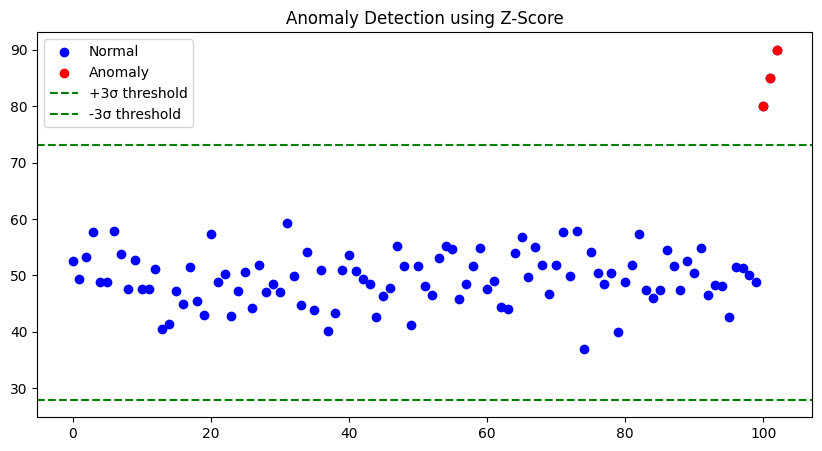

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(df.index, df['transaction_amount'], label="Normal", color='blue')
plt.scatter(df[df['is_anomaly']].index, df[df['is_anomaly']]['transaction_amount'], color='red', label="Anomaly")
plt.axhline(df['transaction_amount'].mean() + 3*df['transaction_amount'].std(), color='green', linestyle='--', label='+3σ threshold')
plt.axhline(df['transaction_amount'].mean() - 3*df['transaction_amount'].std(), color='green', linestyle='--', label='-3σ threshold')
plt.legend()
plt.title("Anomaly Detection using Z-Score")
plt.show()

### IQR method

To identify data points that fall too far below or above the normal range defined by the middle 50% of your data (i.e., between Q1 and Q3).

Q1 - First quartile

Q3 - Third quartile

IQR = Q3 - Q1

A data point x is considered an outlier if:

x < Q1 - 1.5 * IQR OR 
x > Q3 + 1.5 * IQR

It’s non-parametric (doesn’t assume data is normal).

Robust to skewed or non-Gaussian data.

In [ ]:
import numpy as np
import pandas as pd

# Simulate data
np.random.seed(42)
normal_data = np.random.normal(50, 5, 100)
anomalies = np.array([10, 90, 95])
data = np.concatenate((normal_data, anomalies))

df = pd.DataFrame(data, columns=['transaction_amount'])

Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1, " Q3:", Q3, " IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# | is OR symbol in boolean mask of Dataframe
df['is_anomaly'] = (df['transaction_amount'] < lower_bound) | (df['transaction_amount'] > upper_bound)
print(df[df['is_anomaly']])

Q1: 46.9941367446295  Q3: 52.52495396531147  IQR: 5.530817220681968
     transaction_amount  is_anomaly
74            36.901274        True
100           10.000000        True
101           90.000000        True
102           95.000000        True


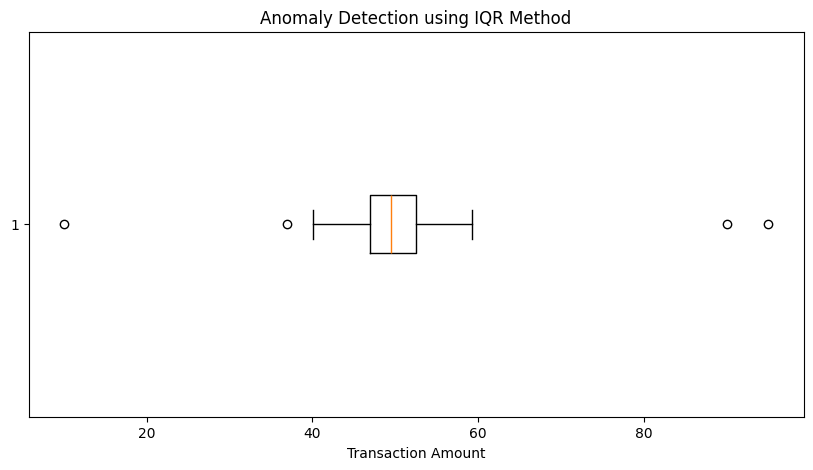

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.boxplot(df['transaction_amount'], vert=False)
plt.title("Anomaly Detection using IQR Method")
plt.xlabel("Transaction Amount")
plt.show()

### How IQR scores over Z-score

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate skewed income data (right skew)
np.random.seed(42)
normal_incomes = np.random.exponential(scale=20000, size=1000) + 40000
extreme_incomes = np.array([500000, 600000, 1000000])  # outliers
data = np.concatenate([normal_incomes, extreme_incomes])
df = pd.DataFrame(data, columns=['income'])

display(df)



,income
0,49385.361800
1,100202.428618
2,66334.913871
3,58258.851076
4,43392.497409
...,...
998,100009.813062
999,51812.020256
1000,500000.000000
1001,600000.000000


In [17]:
mean = df['income'].mean()
std = df['income'].std()
df['z_score'] = (df['income'] - mean) / std
df['z_outlier'] = abs(df['z_score']) > 3

In [18]:
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['iqr_outlier'] = (df['income'] < lower_bound) | (df['income'] > upper_bound)

In [19]:
print("Z-Score detected:", df['z_outlier'].sum(), "outliers")
print("IQR detected:", df['iqr_outlier'].sum(), "outliers")

Z-Score detected: 4 outliers
IQR detected: 44 outliers


In [20]:
df[df['z_outlier']]

,income,iqr_outlier,z_score,z_outlier
531,203448.911956,True,3.404534,True
1000,500000.000000,True,10.510374,True
1001,600000.000000,True,12.906535,True
1002,1000000.000000,True,22.491177,True


In [21]:
df[df['iqr_outlier']]

,income,iqr_outlier,z_score,z_outlier
11,110071.149503,True,1.167053,False
34,107412.606849,True,1.103350,False
50,109856.142655,True,1.161901,False
69,126682.926792,True,1.565098,False
139,111355.962766,True,1.197839,False
140,105640.197291,True,1.060880,False
154,124880.739652,True,1.521915,False
226,112246.188123,True,1.219170,False
241,101551.248256,True,0.962903,False
247,108016.840322,True,1.117829,False


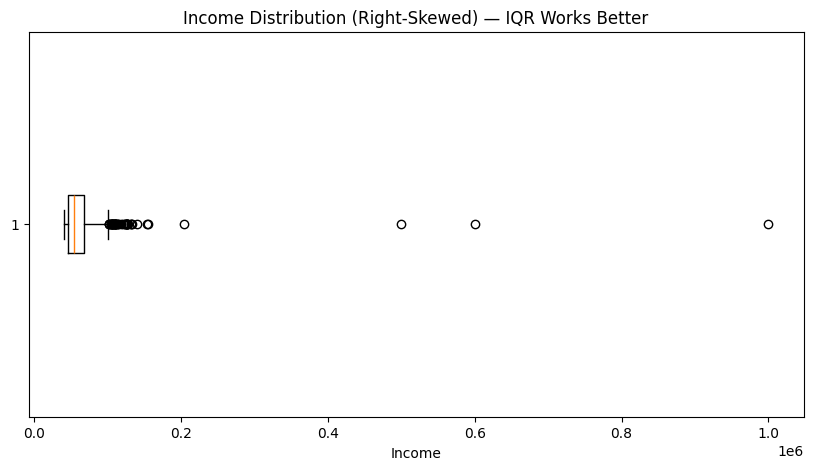

In [11]:
plt.figure(figsize=(10,5))
plt.boxplot(df['income'], vert=False)
plt.title("Income Distribution (Right-Skewed) — IQR Works Better")
plt.xlabel("Income")
plt.show()

Takeaway:

The Z-score method underperforms when your data is not normal — especially for skewed datasets like income, transaction amounts, or sales.

The IQR method is far more robust because it ignores how far tails stretch and focuses on the dense middle of the data.

### Isolation Forest

Instead of trying to define what "normal" data looks like, Isolation Forest focuses on identifying the characteristics of "abnormal" data. The process is as follows: 

1)  Build isolation trees: The algorithm constructs an ensemble of decision-tree-like models called "isolation trees" (iTrees).

2)  Recursive partitioning: Each isolation tree is built by randomly selecting a feature and then randomly selecting a split value for that feature to partition the data. This process is repeated recursively.

3)  Calculate path length: The algorithm measures the number of splits required to isolate a specific data point. This is known as the "path length" from the root node to the final leaf node.

4)  Assign anomaly score:

For normal data points, it takes many random partitions to separate them, resulting in a longer average path length across all the trees.

For anomalies, their distinct nature means they require fewer random splits to be isolated, resulting in a significantly shorter average path length.

The final anomaly score is determined by the average path length of a data point across all the isolation trees. A shorter average path corresponds to a higher anomaly score.

<b> Advantages </b>

Efficiency and scalability: With a linear time complexity and low memory requirements, it is highly efficient and works well with large datasets and high-dimensional problems.

Unsupervised: It does not require labeled data for training, making it ideal for scenarios where anomalies are difficult to label.

No density assumptions: Unlike other methods that assume data follows a specific distribution, Isolation Forest works by isolating data points and does not rely on density or distance calculations.

<b> Disadvantages </b>

Sensitive to parameters: The algorithm's performance can be sensitive to hyperparameter tuning, such as the contamination rate (the expected proportion of anomalies).

Overfitting: It can be prone to overfitting with very small or highly imbalanced datasets.



<img src="./images/isolation_forest_1.png" alt="sample" width="1000"/>

<img src="./images/isolation_forest_2.webp" alt="sample" width="1000"/>

<img src="./images/isolation_forest_3.png" alt="sample" width="1000"/>

,years_exp,role_level,education,salary
0,10.0,1,Masters,75482.075068
1,7.4,3,Bachelors,86573.270258
2,10.6,1,PhD,96327.665820
3,14.1,2,Masters,108928.768300
4,7.1,1,Bachelors,64551.576713
...,...,...,...,...
802,3.0,2,Masters,220.000000
803,28.0,2,Masters,1200.000000
804,30.0,3,PhD,900.000000
805,5.0,4,PhD,500.000000


Detected outliers: 41 of 807

Most anomalous records (lowest scores):
     years_exp  role_level  education         salary  if_score  if_label
804       30.0           3        PhD     900.000000 -0.160199        -1
805        5.0           4        PhD     500.000000 -0.129278        -1
803       28.0           2    Masters    1200.000000 -0.113847        -1
670       13.0           4        PhD  135704.562444 -0.103456        -1
296       11.6           4        PhD  128467.144844 -0.084098        -1
806        0.0           1  Bachelors     100.000000 -0.075377        -1
209       23.4           2  Bachelors  128547.141726 -0.074213        -1
220       17.3           4  Bachelors  135691.160281 -0.068885        -1
800        1.0           1  Bachelors     250.000000 -0.059762        -1
478       20.3           2  Bachelors  128307.468590 -0.056241        -1


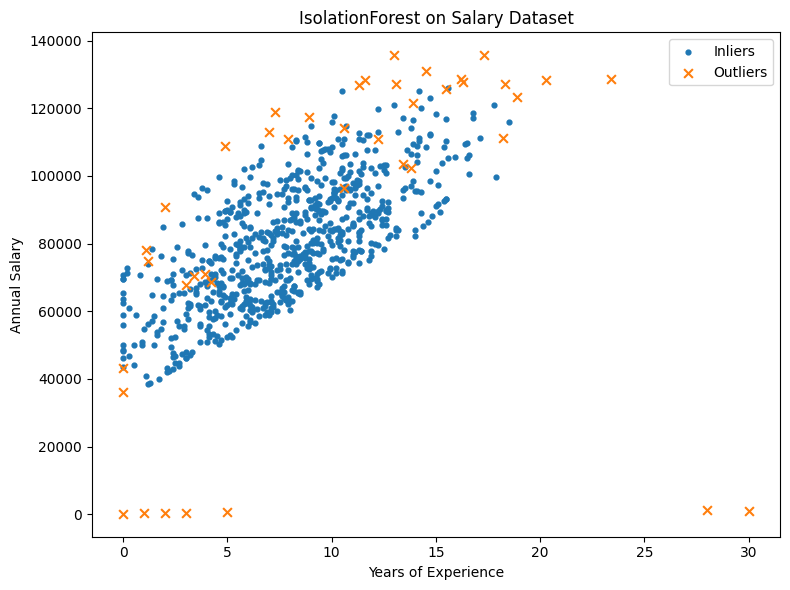

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# -----------------------------
# 1) Build a salary dataset
# -----------------------------
np.random.seed(42)
n = 800

# Core features
years_exp = np.clip(np.random.normal(8, 4, n).round(1), 0, 30)  # 0–30 years
role_level = np.random.choice([1, 2, 3, 4], size=n, p=[0.35, 0.35, 0.2, 0.1])  # junior→lead
education = np.random.choice(["Bachelors", "Masters", "PhD"], size=n, p=[0.6, 0.35, 0.05])

# Base salary model (skewed + noise)
base = 25000 + years_exp * 3500 + role_level * 12000
edu_boost = np.select(
    [education == "Masters", education == "PhD"],
    [8000, 18000],
    default=0
)
salary = base + edu_boost + np.random.lognormal(mean=9.2, sigma=0.25, size=n) - np.exp(9.2)

# Inject some anomalies (implausibly high/low vs profile)
anom_rows = pd.DataFrame({
    "years_exp": [1, 2, 3, 28, 30, 5, 0],
    "role_level": [1, 1, 2, 2, 3, 4, 1],
    "education": ["Bachelors", "Bachelors", "Masters", "Masters", "PhD", "PhD", "Bachelors"],
    "salary": [250, 300, 220, 1200, 900, 500, 100]  # clear outliers
})

df = pd.DataFrame({
    "years_exp": years_exp,
    "role_level": role_level,
    "education": education,
    "salary": salary
})
df = pd.concat([df, anom_rows], ignore_index=True)
display(df)

# Optional: simple encoding for 'education' for the model
df["education_enc"] = df["education"].map({"Bachelors": 0, "Masters": 1, "PhD": 2})

# -----------------------------
# 2) Fit IsolationForest
# -----------------------------
# Choose contamination ~ expected outlier rate (we added 7 in ~807 -> ~0.009), round up a bit
iso = IsolationForest(
    n_estimators=400,
    contamination=0.05,     # tune if needed
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)

features = ["years_exp", "role_level", "education_enc", "salary"]
iso.fit(df[features])

# 3) Get labels and anomaly scores
df["if_label"] = iso.predict(df[features])           # 1=inlier, -1=outlier
df["if_score"] = iso.decision_function(df[features]) # lower -> more anomalous

print("Detected outliers:", (df["if_label"] == -1).sum(), "of", len(df))

# Show the most anomalous rows
print("\nMost anomalous records (lowest scores):")
print(df.nsmallest(10, "if_score")[["years_exp","role_level","education","salary","if_score","if_label"]])

# -----------------------------
# 4) Visualize (salary vs years_exp)
# -----------------------------
plt.figure(figsize=(8,6))
in_mask = df["if_label"] == 1
out_mask = ~in_mask

plt.scatter(df.loc[in_mask, "years_exp"], df.loc[in_mask, "salary"], s=12, label="Inliers")
plt.scatter(df.loc[out_mask, "years_exp"], df.loc[out_mask, "salary"], s=40, marker="x", label="Outliers")

plt.title("IsolationForest on Salary Dataset")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary")
plt.legend()
plt.tight_layout()
plt.show()


### Hyperparameters in Isolation Forest

IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination='auto',
    max_features=1.0,
    bootstrap=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False
)

n_estimators - Number of trees in the forest. More trees = more independent “opinions” → better consensus on what’s normal.

max_samples - Number (or fraction) of samples to draw from the dataset to build each tree. Float (0–1): fraction of dataset (e.g., 0.5 means 50% samples/tree).

contamination - Expected proportion of outliers in the data. Float (0 < c < 0.5): manually specify anomaly rate (e.g., 0.05 = 5% anomalies). Example: If contamination=0.02, the 2% most “isolated” points are flagged as outliers. Start small (0.01–0.05) and tune based on domain knowledge or validation.

max_features - Number (or fraction) of features used to build each tree. Float (0–1): fraction of features per tree (default 1.0 = use all).

bootstrap - default False. Whether samples are drawn with replacement (bootstrap sampling).

# Association Rule Mining

Apriori algorithm

FP-Growth

### Apriori algorithm

Goal - To find frequent itemsets (groups of items that often occur together in transactions) and then generate association rules such as

{Milk, Bread} → {Butter}

It’s used mainly in market basket analysis and other pattern mining tasks.

<style>
table {
  font-family: arial, sans-serif;
  border-collapse: collapse;
  width: 100%;
}

td, th {
  border: 1px solid #dddddd;
  text-align: left;
  padding: 8px;
}

tr:nth-child(even) {
  background-color: #dddddd;
}
</style>

<table>
  <tr>
    <th>Transaction ID</th>
    <th>Items Bought</th>
</tr>
<tr>
    <td>T1</td>
    <td>Milk, Bread, Butter</td>
  </tr>
  <tr>
    <td>T2</td>
    <td>Bread, Butter</td>
  </tr>
    <tr>
    <td>T3</td>
    <td>Milk, Bread</td>
  </tr>
      <tr>
    <td>T4</td>
    <td>Milk, Bread, Butter</td>
  </tr>
        <tr>
    <td>T5</td>
    <td>Bread, Butter</td>
  </tr>
</table>

Steps:

Step 1️⃣ — Generate Candidate Itemsets (C1)

List all individual items and count their Support (frequency).

<table>
  <tr>
    <th>Item</th>
    <th>Support</th>
</tr>
<tr>
    <td>Milk</td>
    <td>3</td>
  </tr>
  <tr>
    <td>Bread</td>
    <td>5</td>
  </tr>
    <tr>
    <td>Butter</td>
    <td>4</td>
</table>

Step 2️⃣ — Apply Minimum Support Threshold

If min support = 60% (i.e., item must appear in ≥3 out of 5 transactions):

Milk ✅ (3/5)

Bread ✅ (5/5)

Butter ✅ (4/5)

Step 3️⃣ — Generate 2-item Candidates (C2)

{Milk, Bread}, {Milk, Butter}, {Bread, Butter}

{Milk, Bread} - 3
{Milk, Butter} - 2
{Bread, Butter} - 4

Step 4️⃣ — Prune by Min Support

Only keep those with support ≥ 60% → i.e., support count ≥ 3.
So, {Milk, Butter} is dropped.

Frequent 2-itemsets (L2) = {Milk, Bread}, {Bread, Butter}

Step 5️⃣ — Generate 3-item Candidates (C3)

Join step:

{Milk, Bread, Butter}

Count support = 2 (appears in T1 and T4)

Support = 2/5 = 40% < 60% → Drop it.

So, no more itemsets remain → algorithm stops.

Step 6️⃣ — Generate Association Rules

From the frequent itemsets, generate rules like:

{Milk} → {Bread}

{Bread} → {Milk}

{Bread} → {Butter}

Then compute:

Support (frequency of the rule)

Confidence (how reliable it is)

Lift (how strong the correlation is beyond chance)

<b> Advantages </b>

✅ Simple and easy to interpret

✅ Works well for small to medium datasets

<b> Disadvantages </b>

❌ High computation cost (many database scans)

❌ Exponential growth of candidates in dense datasets

❌ FP-Growth algorithm is faster for large-scale data


In [26]:
# pip install mlxtend pandas scikit-learn

import random
import pandas as pd
from sklearn.model_selection import train_test_split
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [28]:
transactions = [
    ["milk", "bread", "butter"],
    ["beer", "diapers", "chips"],
    ["milk", "bread"],
    ["bread", "butter"],
    ["milk", "diapers", "bread", "butter"],
    ["beer", "bread"],
    ["milk", "bread", "eggs"],
    ["diapers", "bread", "butter"],
    ["milk", "bread", "butter", "eggs"],
    ["milk", "bread"],
    ["beer", "chips"],
    ["diapers", "beer", "bread"],
    ["milk", "cookies"],
    ["bread", "cookies", "butter"],
]
random.shuffle(transactions)

display(transactions)

[['milk', 'diapers', 'bread', 'butter'],
 ['beer', 'bread'],
 ['diapers', 'beer', 'bread'],
 ['milk', 'bread'],
 ['beer', 'diapers', 'chips'],
 ['bread', 'butter'],
 ['milk', 'bread', 'butter'],
 ['beer', 'chips'],
 ['bread', 'cookies', 'butter'],
 ['milk', 'bread', 'butter', 'eggs'],
 ['milk', 'bread', 'eggs'],
 ['milk', 'cookies'],
 ['milk', 'bread'],
 ['diapers', 'bread', 'butter']]

In [30]:
train_tx, test_tx = train_test_split(transactions, test_size=0.33, random_state=42)

In [31]:
te = TransactionEncoder()
te_ary = te.fit(train_tx).transform(train_tx)
train_df = pd.DataFrame(te_ary, columns=te.columns_)

In [32]:
train_df

,beer,bread,butter,chips,cookies,diapers,eggs,milk
0,False,True,True,False,True,False,False,False
1,True,True,False,False,False,True,False,False
2,True,True,False,False,False,False,False,False
3,False,True,True,False,False,True,False,False
4,True,False,False,True,False,True,False,False
5,True,False,False,True,False,False,False,False
6,False,True,False,False,False,False,True,True
7,False,True,False,False,False,False,False,True
8,False,True,True,False,False,False,False,True


In [35]:
freq = apriori(train_df, min_support=0.3, use_colnames=True)  # tune support
freq = freq.sort_values("support", ascending=False)

In [36]:
freq

,support,itemsets
1,0.777778,(bread)
0,0.444444,(beer)
2,0.333333,(butter)
3,0.333333,(diapers)
4,0.333333,(milk)
5,0.333333,"(butter, bread)"
6,0.333333,"(milk, bread)"


In [24]:
rules = association_rules(freq, metric="confidence", min_threshold=0.5)  # tune confidence
# Keep tidy columns
rules = rules.sort_values(["lift","confidence","support"], ascending=False).reset_index(drop=True)
rules[["antecedents","consequents","support","confidence","lift"]].head()

,antecedents,consequents,support,confidence,lift
0,(butter),(bread),0.444444,1.0,1.125
1,(milk),(bread),0.444444,1.0,1.125
2,(diapers),(bread),0.222222,1.0,1.125
3,"(butter, milk)",(bread),0.222222,1.0,1.125
4,(bread),(butter),0.444444,0.5,1.125


### FP-Growth algorithm

Phase - 1 : FP tree construction

Step 1️⃣ — Count Frequency & Filter by minimum support values

bread - 11

milk - 7

butter - 6

beer - 4

diapers - 4

chips - 2

eggs - 2

cookies - 2

If we set minimum support count = 3, only items that appear ≥ 3 times remain:

Frequent items = { bread, milk, butter, beer, diapers }


Step 2️⃣ — Sort Each Transaction by Frequency

Original Transaction - [milk, bread, butter]

Filtered & Sorted (by global freq) - [bread, milk, butter]

Original Transaction - [beer, diapers, chips]

Filtered & Sorted (by global freq) - [beer, diapers]

Step 3️⃣ — Build FP-Tree

Build the FP-Tree, where:

Each path represents a transaction.

Common prefixes of transactions are merged.

Nodes store item name + count.



<img src="./images/fp_growth_1.png" alt="sample" width="1000"/>


Step 4 - Keep a header table that links all occurrences of the same item.


Phase 2 - Mining Frequent Itemsets

	1.	Start from each item in the header table (lowest frequency first).

	2.	For each item, trace its conditional pattern base (paths that end with that item).

	3.	Build a conditional FP-tree for each item.

	4.	Recursively mine frequent itemsets from these conditional trees.

➡️ This recursive approach finds all frequent patterns efficiently.

### Why it's faster than Apriori

Apriori - Generates many candidate sets and scans the dataset repeatedly. Computationally expensive — exponential candidate growth.
May perform poorly on dense datasets.


FP-Growth - Builds a compact tree once, and mines from it recursively. Compression-based — only scans data twice.
Handles dense data very efficiently.




In [25]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Sample transactions
transactions = [
    ['milk', 'bread', 'butter'],
    ['bread', 'butter'],
    ['milk', 'bread'],
    ['milk', 'bread', 'butter', 'jam'],
    ['bread', 'butter', 'jam'],
    ['milk', 'bread'],
    ['bread', 'butter'],
    ['milk', 'bread', 'butter'],
]

# Encode data
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# FP-Growth mining
frequent_itemsets = fpgrowth(df, min_support=0.4, use_colnames=True)
print("Frequent Itemsets:\n", frequent_itemsets)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
print("\nAssociation Rules:\n", rules[['antecedents','consequents','support','confidence','lift']])

Frequent Itemsets:
    support         itemsets
0    1.000          (bread)
1    0.750         (butter)
2    0.625           (milk)
3    0.750  (bread, butter)
4    0.625    (bread, milk)

Association Rules:
   antecedents consequents  support  confidence  lift
0     (bread)    (butter)    0.750       0.750   1.0
1    (butter)     (bread)    0.750       1.000   1.0
2     (bread)      (milk)    0.625       0.625   1.0
3      (milk)     (bread)    0.625       1.000   1.0


/Users/manojkumar_rajendran/Library/Python/3.13/lib/python/site-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


# Topic modelling

### Latent Dirichlet Allocation

### Count Vectorizer

cv = CountVectorizer(lowercase=True, stop_words='english', min_df=1, ngram_range=(1,1))
X = cv.fit_transform(docs)

CountVectorizer turns a collection of text documents into a numerical matrix where each column is a unique word and each row shows how many times that word appears in a document.

Example documents

docs = ["I love data science", "Data science is fun"]

🪄 Step 1 — Lowercase (because lowercase=True)

["i love data science", "data science is fun"]

 🧹 Step 2 — Remove stopwords (stop_words='english')

Words like “is”  and "i" are removed because they don’t carry meaning.

So, we get

["love", "data", "science"]

["data", "science", "fun"]

🧱 Step 3 — Build Vocabulary (unique words)

Now CountVectorizer creates a list of unique words across all documents. this is called vocabulary

Index   Word

0       data

1       fun

2       love

3       science

Vocabulary = columns of the matrix


🔢 Step 4 — Count how many times each word appears in each document


<img src="./images/lda_1.png" alt="sample" width="1000"/>

💾 Step 5 — Store as a matrix

This is what cv.fit_transform(docs) produces internally — produces a Document-Term Matrix (DTM) for the Bag-of-Words representation:

[[1, 0, 1, 1],
 [1, 1, 0, 1]]

⚙️ Why CountVectorizer uses a sparse matrix by default

Because for real-world datasets (thousands of documents, tens of thousands of words), most entries are zero — so storing all zeros wastes memory. Sparse format saves only nonzero counts efficiently.


### LDA


LDA assumes every document talks about multiple hidden topics in different proportions.

🧩 1️⃣ Each document is a mixture of topics

For example:

Doc 1 = 80% Politics + 20% Sports (A news story can talk about sports and politics)

Doc 2 = 60% Technology + 40% Business

🧠 So: one document → many topics (soft assignment, not one-topic-per-doc). 

🧱 2️⃣ Each topic is a mixture of words

Each topic has its own set of words that it “likes” more.

Politics → {government, election, law, minister}

Sports → {match, goal, team, win}

Topics are probability distributions over words — not fixed word lists.

Words that co-occur across documents get grouped into the same topic.

🧩 5️⃣ Words are exchangeable (bag-of-words assumption)

LDA assumes word order doesn’t matter within a document.

The only thing that matters is how many times each word appears.

That’s why we feed it the Document-Term Matrix (DTM).

6️⃣ Fixed number of topics (K)

LDA assumes we decide beforehand how many topics (K) to find.

It will force every document and every word distribution to use those K topics.


In [37]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

docs = [
    "I love data science",
    "Data science is fun",
]

# Each alphabet can be encoded into its position

# 1) DTM (Count, not TF-IDF)
cv = CountVectorizer(lowercase=True, stop_words='english')
X = cv.fit_transform(docs)
terms = cv.get_feature_names_out()

# 2) Fit LDA
lda = LatentDirichletAllocation(n_components=2, random_state=0)
lda.fit(X)

# 3) Topics: top words per topic
for k, topic in enumerate(lda.components_):
    top = topic.argsort()[-5:][::-1]
    print(f"Topic {k+1}:", ", ".join(terms[i] for i in top))

# 4) Document mixtures
theta = lda.transform(X)
print("Document-topic mixtures:\n", np.round(theta, 3))

Topic 1: data, science, love, fun
Topic 2: science, data, fun, love
Document-topic mixtures:
 [[0.821 0.179]
 [0.179 0.821]]


In [40]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import pandas as pd

docs = [
    "Election results were announced today",
    "The government passed a new education bill",
    "The football team won the championship",
    "Fans celebrated the exciting match win",
    "Parliament debated the national budget",
    "The player scored two goals in the final",
]

# 1) Vectorize (Count, not TF-IDF, for LDA)
cv = CountVectorizer(lowercase=True, stop_words='english', min_df=1, ngram_range=(1,1))

X = cv.fit_transform(docs)
terms = cv.get_feature_names_out()
dtm = pd.DataFrame(X.toarray(), columns=terms)
print(dtm)

# 2) Fit LDA
lda = LatentDirichletAllocation(
    n_components=10,       # K topics
    learning_method='batch',
    random_state=42
)
lda.fit(X)

# 3) Show top words per topic
terms = cv.get_feature_names_out()
def show_topics(model, n_top_words=8):
    for k, topic in enumerate(model.components_):
        top_ids = topic.argsort()[-n_top_words:][::-1]
        print(f"Topic {k+1}: " + ", ".join(terms[i] for i in top_ids))
show_topics(lda)

# 4) Document-topic mixtures
theta = lda.transform(X)   # rows=docs, cols=topics
print("\nDocument → topic proportions:")
for i, row in enumerate(theta):
    mix = ", ".join([f"T{j+1}:{row[j]:.2f}" for j in range(row.shape[0])])
    print(f"D{i+1}: {mix}")

   announced  budget  celebrated  championship  debated  education  election  \
0          1       0           0             0        0          0         1   
1          0       0           0             0        0          1         0   
2          0       0           0             1        0          0         0   
3          0       0           1             0        0          0         0   
4          0       1           0             0        1          0         0   
5          0       0           0             0        0          0         0   

   exciting  fans  final  ...  new  parliament  passed  player  results  \
0         0     0      0  ...    0           0       0       0        1   
1         0     0      0  ...    1           0       1       0        0   
2         0     0      0  ...    0           0       0       0        0   
3         1     1      0  ...    0           0       0       0        0   
4         0     0      0  ...    0           1       0       0  